
--- Optimizing alpha_cc ---
Top 3 Best Fitting Global Models:
                          file  alpha_cc  alpha_Ia  gcc  gIa/gcc  Upsilon  \
0  models/alpha_cc_iter1_5.csv       0.5       0.3  0.4        2        1   
1  models/alpha_cc_iter1_6.csv       0.6       0.3  0.4        2        1   
2  models/alpha_cc_iter1_7.csv       0.7       0.3  0.4        2        1   

   chi2_total  reduced_chi2  n_points  
0    4.352624      0.002910      1496  
1    4.410451      0.002948      1496  
2    7.061177      0.004720      1496  

The best fit is models/alpha_cc_iter1_5.csv with alpha_cc = 0.5, alpha_Ia = 0.3, gcc = 0.4, gIa/gcc = 2, Upsilon = 1

The best fit is models/alpha_cc_iter1_5.csv...


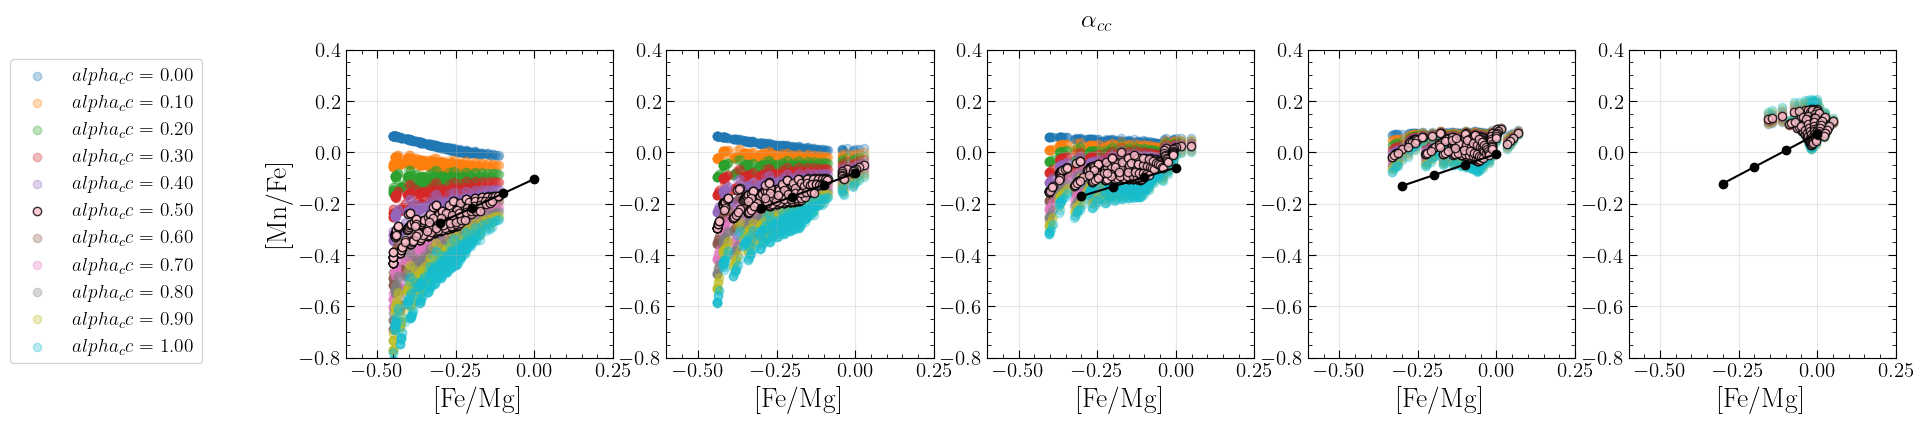


--- Optimizing alpha_Ia ---
Top 3 Best Fitting Global Models:
                    file  alpha_cc  alpha_Ia  gcc  gIa/gcc  Upsilon  \
0  models/alpha_Ia_4.csv       0.5       0.4  0.4        2        1   
1  models/alpha_Ia_3.csv       0.5       0.3  0.4        2        1   
2  models/alpha_Ia_5.csv       0.5       0.5  0.4        2        1   

   chi2_total  reduced_chi2  n_points  
0    4.060292      0.002714      1496  
1    4.352624      0.002910      1496  
2    5.095837      0.003406      1496  

The best fit is models/alpha_Ia_4.csv with alpha_cc = 0.5, alpha_Ia = 0.4, gcc = 0.4, gIa/gcc = 2, Upsilon = 1

The best fit is models/alpha_Ia_4.csv...


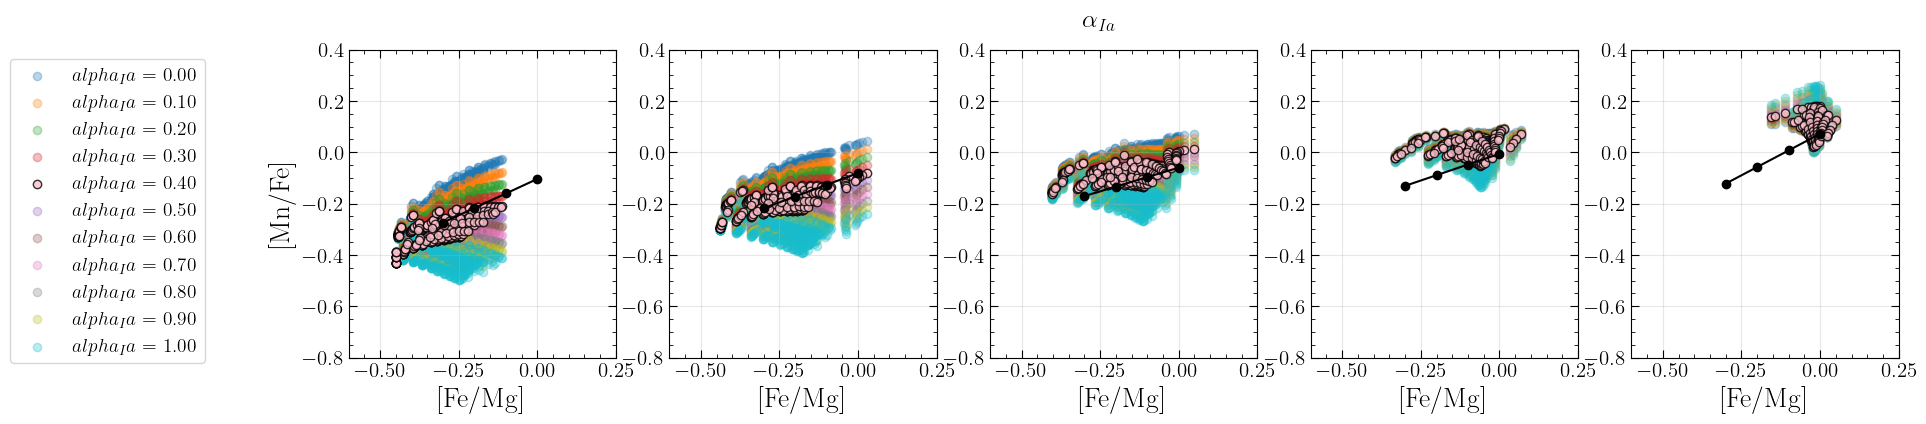


--- Optimizing gcc ---
Top 3 Best Fitting Global Models:
                      file  alpha_cc  alpha_Ia   gcc  gIa/gcc  Upsilon  \
0  models/g_cc_iter1_6.csv       0.5       0.4  0.40        2        1   
1  models/g_cc_iter1_5.csv       0.5       0.4  0.35        2        1   
2  models/g_cc_iter1_7.csv       0.5       0.4  0.45        2        1   

   chi2_total  reduced_chi2  n_points  
0    4.060292      0.002714      1496  
1    6.249059      0.004177      1496  
2   10.481735      0.007007      1496  

The best fit is models/g_cc_iter1_6.csv with alpha_cc = 0.5, alpha_Ia = 0.4, gcc = 0.4000000000000001, gIa/gcc = 2, Upsilon = 1

The best fit is models/g_cc_iter1_6.csv...


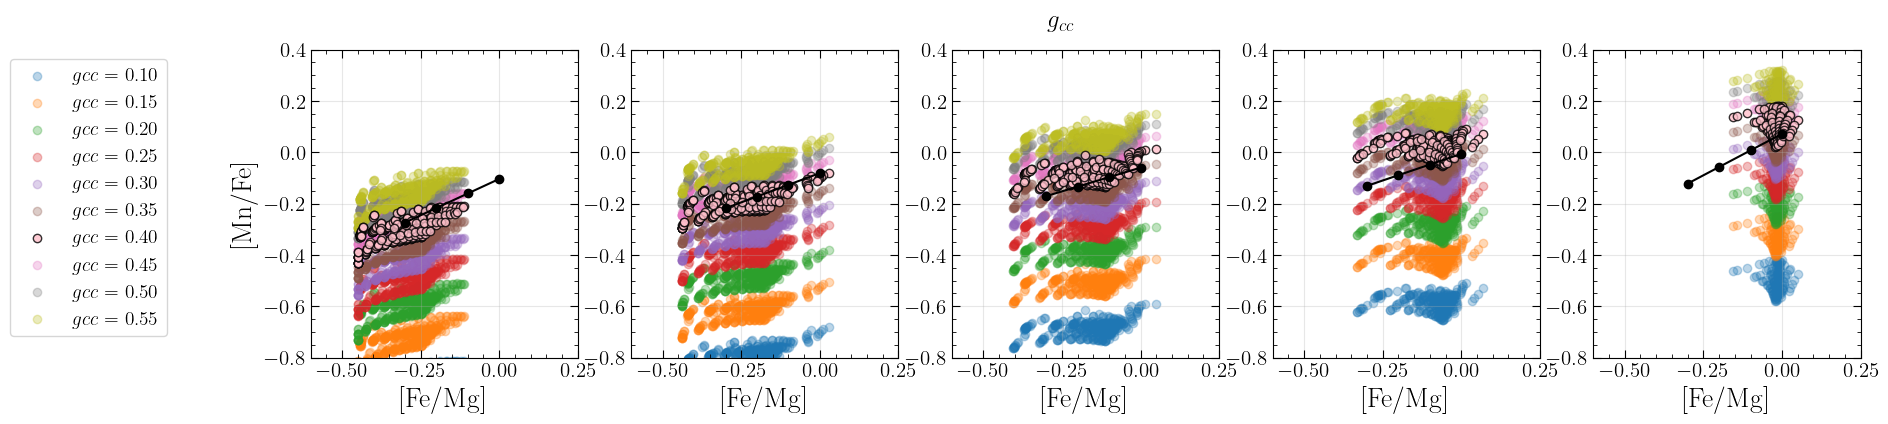


--- Optimizing gIa/gcc ---
Top 3 Best Fitting Global Models:
                          file  alpha_cc  alpha_Ia  gcc  gIa/gcc  Upsilon  \
0   models/g_ratio_iter1_9.csv       0.5       0.4  0.4      1.9        1   
1   models/g_ratio_iter1_8.csv       0.5       0.4  0.4      1.7        1   
2  models/g_ratio_iter1_10.csv       0.5       0.4  0.4      2.1        1   

   chi2_total  reduced_chi2  n_points  
0    3.700957      0.002474      1496  
1    4.211332      0.002815      1496  
2    4.783086      0.003197      1496  

The best fit is models/g_ratio_iter1_9.csv with alpha_cc = 0.5, alpha_Ia = 0.4, gcc = 0.4, gIa/gcc = 1.9000000000000004, Upsilon = 1

The best fit is models/g_ratio_iter1_9.csv...


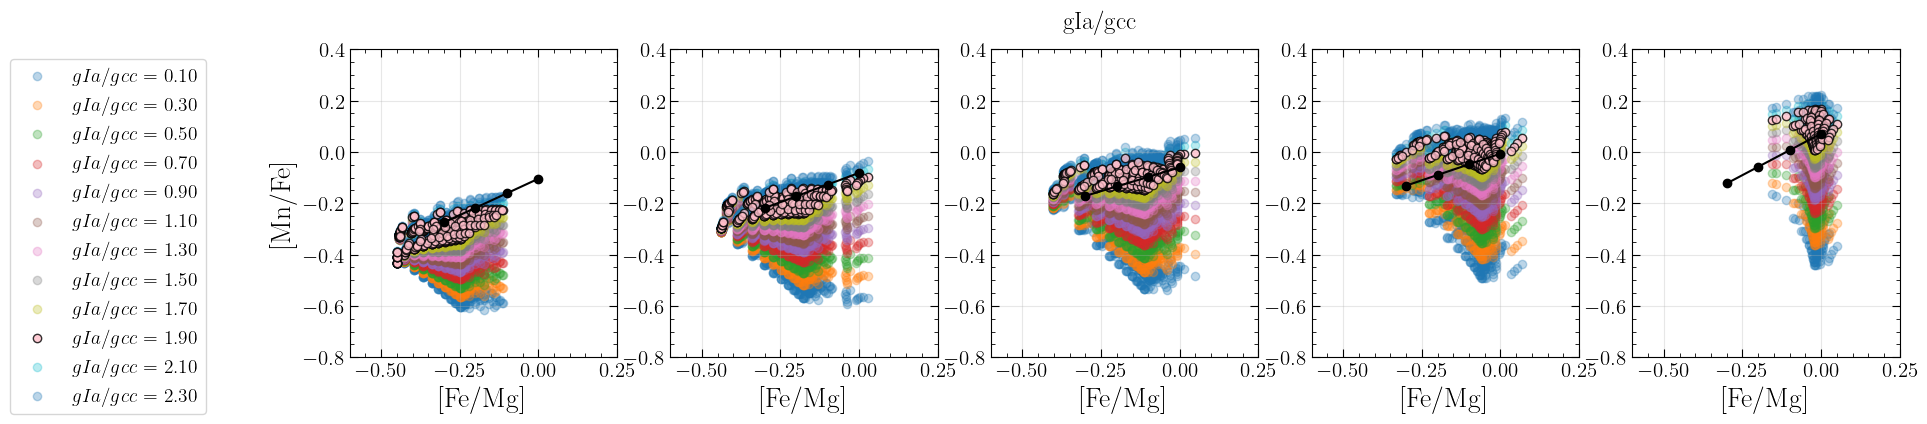

In [5]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 1. Global Plotting Parameters
params = {
   'axes.labelsize': 20, 'font.size': 15, 'legend.fontsize': 14,
   'xtick.minor.visible': True, 'ytick.minor.visible': True,
   'xtick.labelsize': 15, 'ytick.labelsize': 15, 'text.usetex': True,
   'font.family':'serif', 'axes.titlesize': 20, 'xtick.direction': 'in',
   'ytick.direction': 'in', 'xtick.top': True, 'ytick.right': True,
   'xtick.major.size': 6, 'xtick.minor.size': 3,
   'ytick.major.size': 6, 'ytick.minor.size': 3
}
rcParams.update(params)

# 2. One-time Setup: Data Loading & Bin Definitions
summary_df = pd.read_csv("data_fitted_line_in_bins_of_mg_h.csv")
summary_df['mg_h_bin_round'] = summary_df['mg_h_bin_center'].round(3)

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])

def compute_mn_fe_model(row, fe_centers):
    return (row['slope_mn_fe'] * fe_centers) + row['intercept_mn_fe']

summary_df['mn_fe_model_vals'] = summary_df.apply(
    lambda r: compute_mn_fe_model(r, fe_mg_centers).tolist(), axis=1
)

# 3. Main Optimization & Plotting Function
def optimize_and_plot(param_name, file_pattern, plot_prefix, num_plot_files):
    print(f"\n--- Optimizing {param_name} ---")
    
    # --- A. Chi-Square Calculation ---
    model_files = glob.glob(file_pattern)
    chi2_results = []

    for file in model_files:
        model_df = pd.read_csv(file)
        model_df['mg_h_bin_round'] = model_df['mg_h_bin'].round(3)
        
        merged_df = pd.merge(model_df, summary_df, on='mg_h_bin_round', how='inner')
        merged_df = merged_df.dropna(subset=['slope_mn_fe', 'intercept_mn_fe'])
        
        if len(merged_df) == 0:
            continue

        expected_mn_fe = (merged_df['slope_mn_fe'] * merged_df['fe_mg']) + merged_df['intercept_mn_fe']
        residuals_sq = (merged_df['mn_fe'] - expected_mn_fe)**2
        
        n_points = len(residuals_sq)
        chi2_total = residuals_sq.sum()
        
        chi2_results.append({
            'file': file,
            'alpha_cc': merged_df['alpha_cc'].iloc[0],
            'alpha_Ia': merged_df['alpha_Ia'].iloc[0],
            'gcc': merged_df['gcc'].iloc[0],
            'gIa/gcc': merged_df['gIa/gcc'].iloc[0],
            'Upsilon': merged_df['Upsilon'].iloc[0],
            'chi2_total': chi2_total,
            'reduced_chi2': chi2_total / n_points,
            'n_points': n_points
        })

    results_df = pd.DataFrame(chi2_results).sort_values(by='reduced_chi2').reset_index(drop=True)
    
    print("Top 3 Best Fitting Global Models:")
    print(results_df.head(3))
    
    best_model = results_df.iloc[0]
    print(f"\nThe best fit is {best_model['file']} with alpha_cc = {best_model['alpha_cc']}, "
          f"alpha_Ia = {best_model['alpha_Ia']}, gcc = {best_model['gcc']}, "
          f"gIa/gcc = {best_model['gIa/gcc']}, Upsilon = {best_model['Upsilon']}")
    
    best_model = results_df.iloc[0]
    best_val = best_model[param_name] # <--- ADD THIS LINE
    print(f"\nThe best fit is {best_model['file']}...")

    # --- B. Plotting ---
    # Load data for plotting bins
    dfs = []
    for i in range(num_plot_files): # Assuming you want to read all available iteration files
        try:
            dfs.append(pd.read_csv(f'models/{plot_prefix}_{i}.csv'))
        except FileNotFoundError:
            continue
            
    if not dfs:
        print("No files found for plotting.")
        return

    df_all = pd.concat(dfs, ignore_index=True)
    mg_h_bins = df_all['mg_h_bin'].unique()

    plt.figure(figsize=(20, 4))
    
    for i in range(min(5, len(mg_h_bins))): # Ensure we don't index out of bounds
        plt.subplot(1, 5, i+1)

        for j in range(num_plot_files):
            try:
                model = pd.read_csv(f"models/{plot_prefix}_{j}.csv")
            except FileNotFoundError:
                continue
                
            mask = np.isclose(model['mg_h_bin'], mg_h_bins[i])
            subset = model[mask]
            
            if len(subset) == 0: continue

            # Plot model scatter
            # Plot model scatter
            val = subset[param_name].iloc[0]
            if np.isclose(val, best_val): # <--- CHANGE THIS LINE
                plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.8, color='pink', 
                            edgecolors='black', label=rf"${param_name}$ = {val:.2f}", zorder=10)
            else:
                plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.3, 
                            label=rf"${param_name}$ = {val:.2f}")

        # Plot data lines
        mask_data = np.isclose(summary_df['mg_h_bin_center'], mg_h_bins[i])
        data_subset = summary_df[mask_data]
        
        if len(data_subset) > 0:
            mn_fe_model_vals = np.asarray(data_subset['mn_fe_model_vals'].iloc[0])
            plt.plot(fe_mg_centers, mn_fe_model_vals, color='black', marker='o', zorder=12)
            
        if i == 0:
            plt.ylabel('[Mn/Fe]')
            plt.legend(bbox_to_anchor=[-0.5, 1])
            
        plt.grid(True, alpha=0.3)
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.xlabel('[Fe/Mg]')

    # Format the title depending on the parameter string
    title_map = {'alpha_cc': r"$\alpha_{cc}$", 'alpha_Ia': r"$\alpha_{Ia}$", 'gcc': r"$g_{cc}$"}
    plt.suptitle(title_map.get(param_name, param_name))
    plt.show()

# 4. Execute the 1D Iterations
optimize_and_plot(param_name='alpha_cc', file_pattern="models/alpha_cc_iter1_*.csv", plot_prefix="alpha_cc_iter1", num_plot_files=11)

optimize_and_plot(param_name='alpha_Ia', file_pattern="models/alpha_Ia_*.csv", plot_prefix="alpha_Ia", num_plot_files=11)

optimize_and_plot(param_name='gcc', file_pattern="models/g_cc_iter1_*.csv", plot_prefix="g_cc_iter1", num_plot_files=10)

optimize_and_plot(param_name='gIa/gcc', file_pattern="models/g_ratio_iter1_*.csv", plot_prefix="g_ratio_iter1", num_plot_files=13)


--- Optimizing alpha_cc ---
Top 3 Best Fitting Global Models:
                          file  alpha_cc  alpha_Ia  gcc  gIa/gcc  Upsilon  \
0  models/alpha_cc_iter2_4.csv      0.48       0.4  0.4      1.9        1   
1  models/alpha_cc_iter2_3.csv      0.46       0.4  0.4      1.9        1   
2  models/alpha_cc_iter2_5.csv      0.50       0.4  0.4      1.9        1   

   chi2_total  reduced_chi2  n_points  
0    3.577295      0.002391      1496  
1    3.593098      0.002402      1496  
2    3.700957      0.002474      1496  

The best fit is models/alpha_cc_iter2_4.csv with alpha_cc = 0.4800000000000001, alpha_Ia = 0.4, gcc = 0.4, gIa/gcc = 1.9, Upsilon = 1

The best fit is models/alpha_cc_iter2_4.csv...


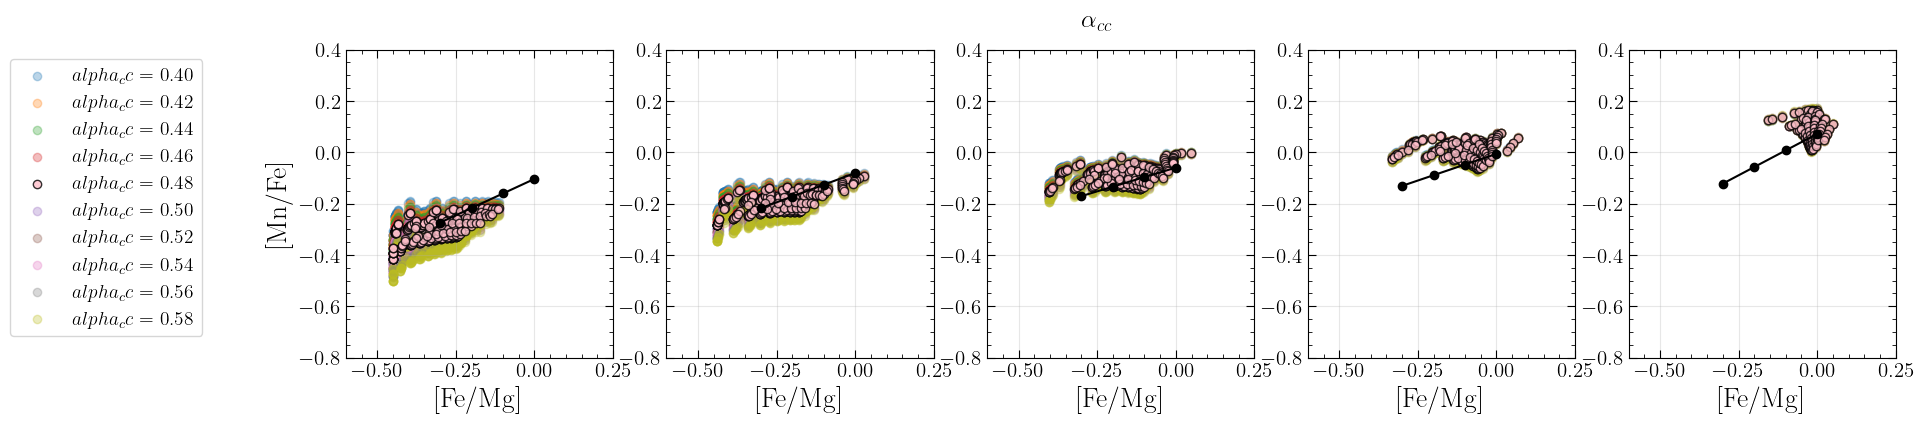

In [6]:
optimize_and_plot(param_name='alpha_cc', file_pattern="models/alpha_cc_iter2_*.csv", plot_prefix="alpha_cc_iter2", num_plot_files=10)


--- Optimizing alpha_Ia ---
Top 3 Best Fitting Global Models:
                          file  alpha_cc  alpha_Ia  gcc  gIa/gcc  Upsilon  \
0  models/alpha_Ia_iter2_3.csv      0.48      0.36  0.4      1.9        1   
1  models/alpha_Ia_iter2_2.csv      0.48      0.34  0.4      1.9        1   
2  models/alpha_Ia_iter2_4.csv      0.48      0.38  0.4      1.9        1   

   chi2_total  reduced_chi2  n_points  
0    3.423851      0.002289      1496  
1    3.425373      0.002290      1496  
2    3.475303      0.002323      1496  

The best fit is models/alpha_Ia_iter2_3.csv with alpha_cc = 0.48, alpha_Ia = 0.36, gcc = 0.4, gIa/gcc = 1.9, Upsilon = 1

The best fit is models/alpha_Ia_iter2_3.csv...


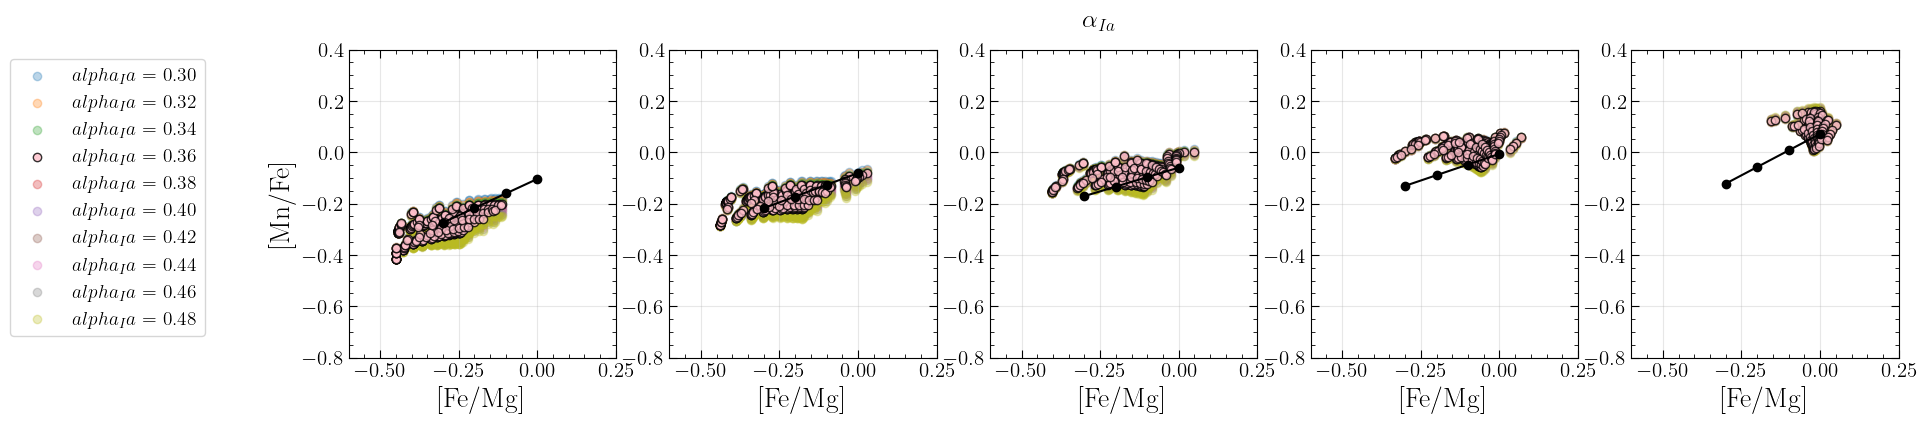

In [8]:
optimize_and_plot(param_name='alpha_Ia', file_pattern="models/alpha_Ia_iter2_*.csv", plot_prefix="alpha_Ia_iter2", num_plot_files=10)


--- Optimizing gcc ---
Top 3 Best Fitting Global Models:
                      file  alpha_cc  alpha_Ia   gcc  gIa/gcc  Upsilon  \
0  models/g_cc_iter2_4.csv      0.48      0.36  0.38      1.9        1   
1  models/g_cc_iter2_5.csv      0.48      0.36  0.40      1.9        1   
2  models/g_cc_iter2_3.csv      0.48      0.36  0.36      1.9        1   

   chi2_total  reduced_chi2  n_points  
0    2.966051      0.001983      1496  
1    3.423851      0.002289      1496  
2    4.090826      0.002735      1496  

The best fit is models/g_cc_iter2_4.csv with alpha_cc = 0.48, alpha_Ia = 0.36, gcc = 0.38, gIa/gcc = 1.9, Upsilon = 1

The best fit is models/g_cc_iter2_4.csv...


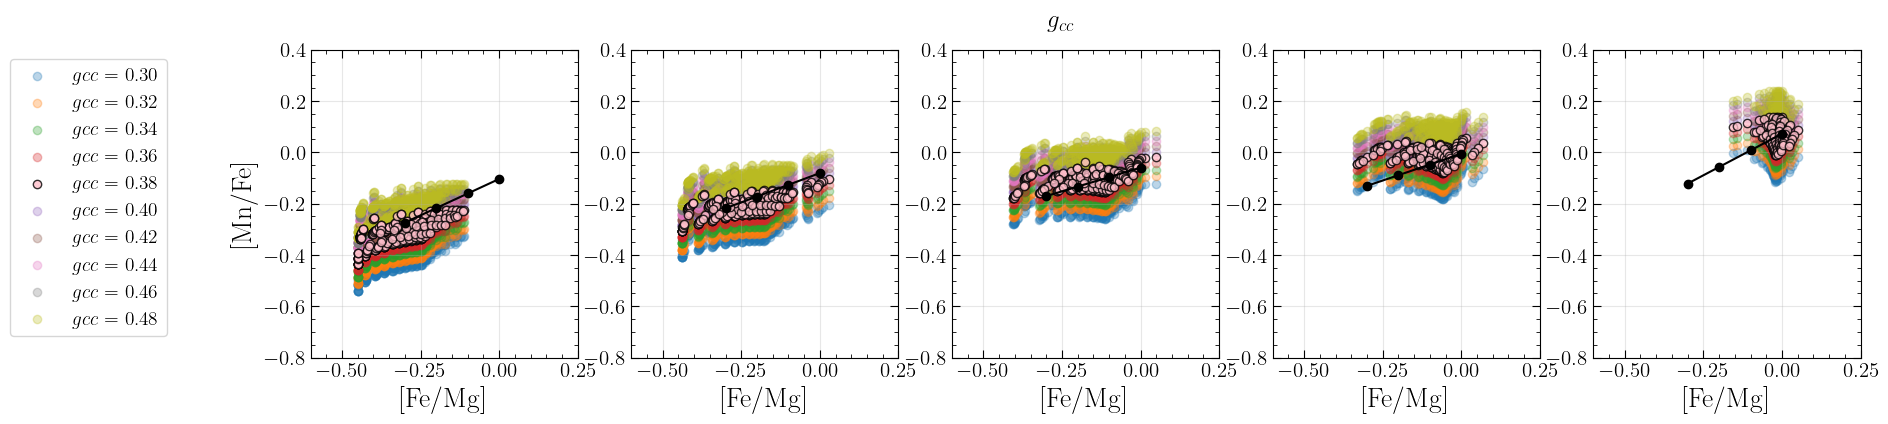

In [10]:
optimize_and_plot(param_name='gcc', file_pattern="models/g_cc_iter2_*.csv", plot_prefix="g_cc_iter2", num_plot_files=10)


--- Optimizing gIa/gcc ---
Top 3 Best Fitting Global Models:
                          file  alpha_cc  alpha_Ia   gcc  gIa/gcc  Upsilon  \
0   models/g_ratio_iter2_9.csv      0.48      0.36  0.38     1.95        1   
1   models/g_ratio_iter2_8.csv      0.48      0.36  0.38     1.90        1   
2  models/g_ratio_iter2_10.csv      0.48      0.36  0.38     2.00        1   

   chi2_total  reduced_chi2  n_points  
0    2.918326      0.001951      1496  
1    2.966051      0.001983      1496  
2    2.969411      0.001985      1496  

The best fit is models/g_ratio_iter2_9.csv with alpha_cc = 0.48, alpha_Ia = 0.36, gcc = 0.38, gIa/gcc = 1.9500000000000004, Upsilon = 1

The best fit is models/g_ratio_iter2_9.csv...


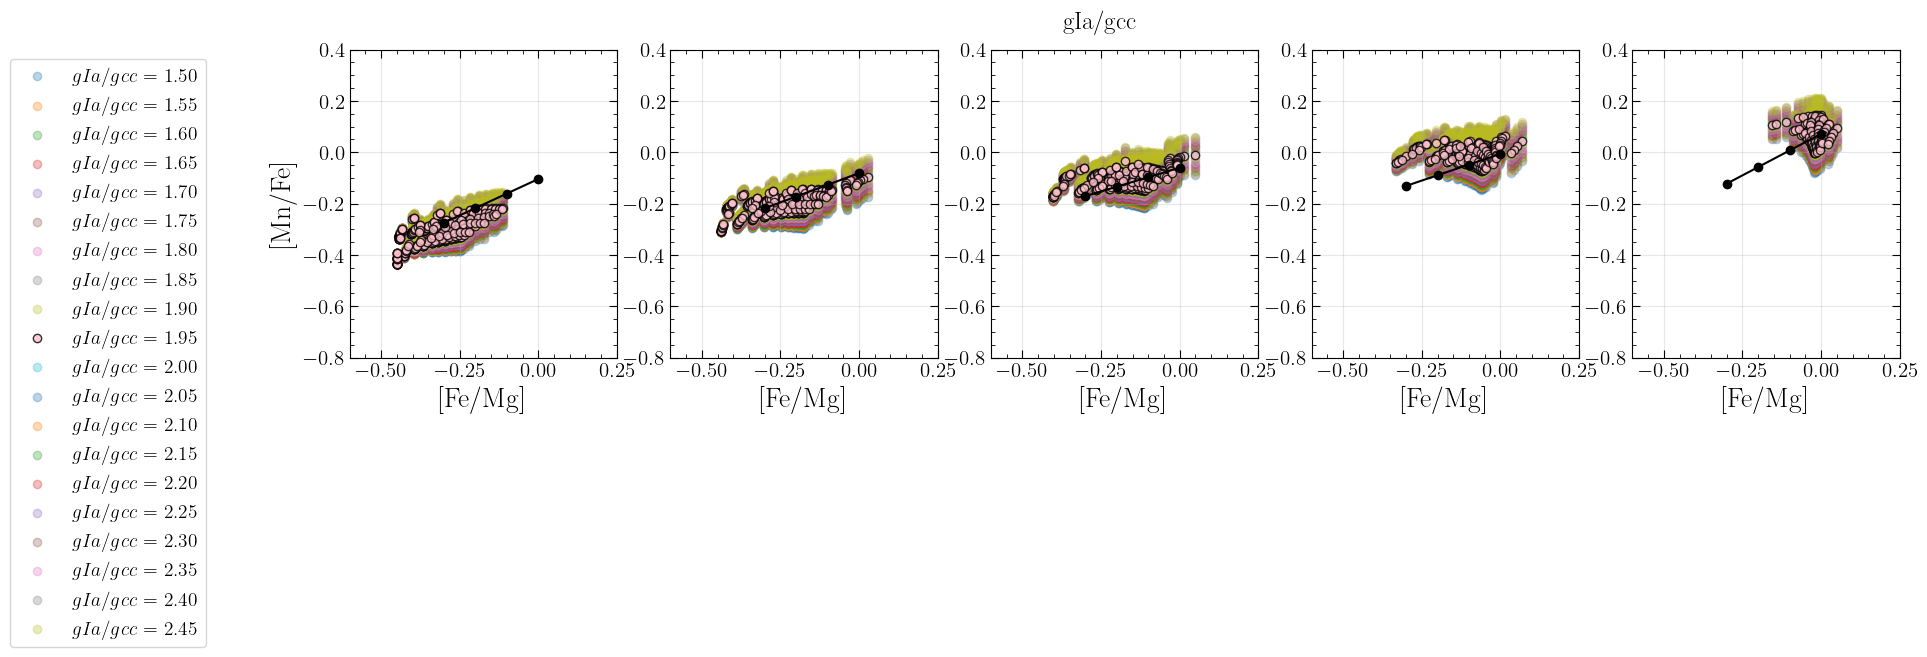

In [12]:
optimize_and_plot(param_name='gIa/gcc', file_pattern="models/g_ratio_iter2_*.csv", plot_prefix="g_ratio_iter2", num_plot_files=20)